# Tugas Praktikum 11: Logistic Regression
**Topik:** Prediksi Tingkat Stres Mahasiswa  
**Dataset:** Survei Beban Tugas & Tingkat Stres Mahasiswa (Form Responses 1)

## 1. Membaca Dataset
Menggunakan pustaka `pandas` untuk memuat data dari file CSV yang baru.

In [1]:
import pandas as pd
import numpy as np

# Membaca dataset yang baru
filename = 'Survei Beban Tugas & Tingkat Stres Mahasiswa  (Jawaban)(Form Responses 1).csv'
df = pd.read_csv(filename)

# Menampilkan 5 data teratas
df.head()

,Timestamp,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress?,Stress
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1


## 2. Data Cleaning
Melakukan pembersihan data: menghapus missing values dan memastikan format kolom sesuai.

In [2]:
# Menghapus kolom identitas
df_clean = df.drop(columns=['Timestamp', 'Nama Lengkap', 'NIM', 'Stress?'], errors='ignore')

# Mengubah nama kolom agar seragam
df_clean.columns = ['jml_tugas', 'tugas_deadline', 'jam_tidur', 'stress']

# 1. Menghapus data kosong (missing value)
df_clean = df_clean.dropna()

# 2. Memastikan format angka konsisten
cols_to_fix = ['jml_tugas', 'tugas_deadline', 'jam_tidur']
for col in cols_to_fix:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Hapus baris yang gagal dikonversi ke angka
df_clean = df_clean.dropna()

print('Data setelah dibersihkan:')
display(df_clean.head())

Data setelah dibersihkan:


,jml_tugas,tugas_deadline,jam_tidur,stress
0,5,5,7,1
1,2,1,10,0
2,1,0,4,0
3,4,2,6,0
4,5,1,5,1


## 3. Feature Selection
Memisahkan fitur (X) dan target (y).

In [3]:
# Fitur: jml_tugas, tugas_deadline, jam_tidur
X = df_clean[['jml_tugas', 'tugas_deadline', 'jam_tidur']]

# Target: Stress (sudah angka 0/1 di dataset ini)
y = df_clean['stress']

print('Fitur (X):')
display(X.head())
print('\nTarget (y):')
display(y.head())

Fitur (X):


,jml_tugas,tugas_deadline,jam_tidur
0,5,5,7
1,2,1,10
2,1,0,4
3,4,2,6
4,5,1,5



Target (y):


0    1
1    0
2    0
3    0
4    1
Name: stress, dtype: int64

## 4. Split Data
Membagi dataset menjadi data training (80%) dan data testing (20%).

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Jumlah data training: {len(X_train)}')
print(f'Jumlah data testing: {len(X_test)}')

Jumlah data training: 33
Jumlah data testing: 9


## 5. Training Model
Melatih model menggunakan `LogisticRegression()`.

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print('Model berhasil dilatih!')

Model berhasil dilatih!


## 6. Prediction
Melakukan prediksi pada data testing.

In [6]:
y_pred = model.predict(X_test)
print('Hasil prediksi:')
print(y_pred)

Hasil prediksi:
[1 0 0 1 1 0 0 1 0]


## 7. Evaluation
Menampilkan metrik evaluasi.

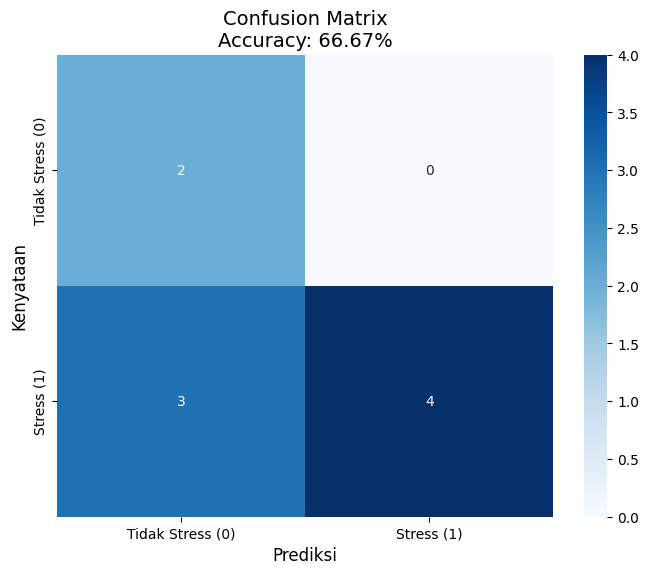


  CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Tidak Stress (0)       0.40      1.00      0.57         2
      Stress (1)       1.00      0.57      0.73         7

        accuracy                           0.67         9
       macro avg       0.70      0.79      0.65         9
    weighted avg       0.87      0.67      0.69         9



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Menghitung Accuracy
acc = accuracy_score(y_test, y_pred)

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# --- VISUALISASI ---

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Stress (0)', 'Stress (1)'], 
            yticklabels=['Tidak Stress (0)', 'Stress (1)'])
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Kenyataan', fontsize=12)
plt.show()

# 3. Menampilkan Classification Report
print("\n" + "="*25)
print("  CLASSIFICATION REPORT")
print("="*25)
print(classification_report(y_test, y_pred, target_names=['Tidak Stress (0)', 'Stress (1)']))

## 8. Probabilitas Prediksi
Menampilkan probabilitas menggunakan `predict_proba()`.

In [8]:
probs = model.predict_proba(X_test)

print("Probabilitas Hasil Prediksi (10 data pertama):")
print("-" * 50)
for i in range(min(10, len(X_test))):
    p_tidak = probs[i][0]
    p_stress = probs[i][1]
    print(f"Data {i+1}: {probs[i]} -> {p_tidak*100:.0f}% Tidak Stress, {p_stress*100:.0f}% Stress")

Probabilitas Hasil Prediksi (10 data pertama):
--------------------------------------------------
Data 1: [0.42708726 0.57291274] -> 43% Tidak Stress, 57% Stress
Data 2: [0.60001978 0.39998022] -> 60% Tidak Stress, 40% Stress
Data 3: [0.5703923 0.4296077] -> 57% Tidak Stress, 43% Stress
Data 4: [0.23144316 0.76855684] -> 23% Tidak Stress, 77% Stress
Data 5: [0.35669957 0.64330043] -> 36% Tidak Stress, 64% Stress
Data 6: [0.67261513 0.32738487] -> 67% Tidak Stress, 33% Stress
Data 7: [0.52736628 0.47263372] -> 53% Tidak Stress, 47% Stress
Data 8: [0.22491869 0.77508131] -> 22% Tidak Stress, 78% Stress
Data 9: [0.78847645 0.21152355] -> 79% Tidak Stress, 21% Stress
